Loading news data...
News cleaned: (55987, 6) rows, date range 2011-04-27 00:00:00 to 2020-06-11 00:00:00
Computing sentiment (this may take a few minutes)...
Sentiment computed.
Daily sentiment records: 44196

Processing AAPL...
  Overlapping days: 2
  Too few overlapping days for reliable correlation.

Processing AMZN...
  Overlapping days: 2
  Too few overlapping days for reliable correlation.

Processing GOOG...
  Overlapping days: 5
  Pearson correlation: -0.2344 (p-value: 0.7044)

Processing META...
  No news for META.

Processing NVDA...
  Overlapping days: 4
  Pearson correlation: 0.5227 (p-value: 0.4773)

Summary of Sentiment-Return Correlations
ticker  correlation  p_value  n_days
  AAPL          NaN      NaN       2
  AMZN          NaN      NaN       2
  GOOG    -0.234365 0.704352       5
  META          NaN      NaN       0
  NVDA     0.522731 0.477269       4


C:\Users\lenovo\AppData\Local\Temp\ipykernel_2112\1234382035.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=corr_data, x='ticker', y='correlation', palette='coolwarm')


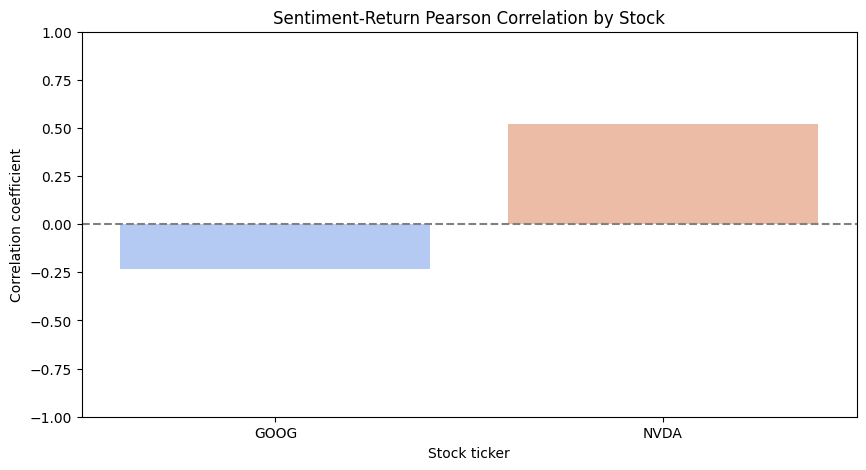

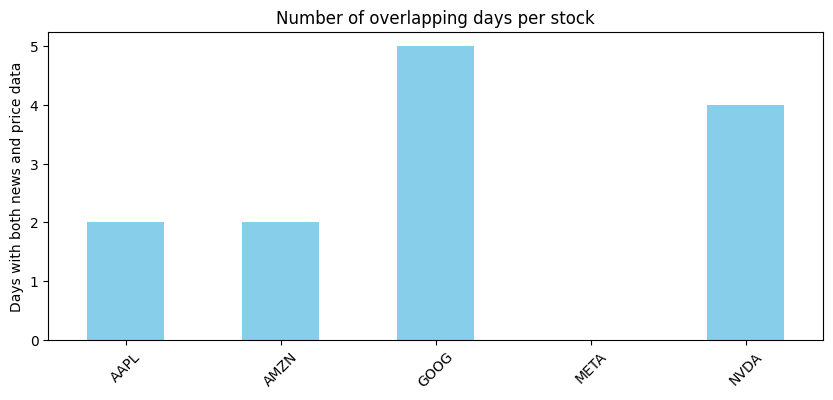

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy.stats import pearsonr
import os

# --------------------------------------------
# 1. Load and clean news
# --------------------------------------------
print("Loading news data...")
news = pd.read_csv('../data/raw/raw_analyst_ratings.csv', index_col=0)
news['date'] = pd.to_datetime(news['date'], errors='coerce')
news['date'] = news['date'].dt.tz_localize(None)
news = news.dropna(subset=['date'])
news['date_only'] = news['date'].dt.normalize()
print(f"News cleaned: {news.shape} rows, date range {news['date_only'].min()} to {news['date_only'].max()}")

# --------------------------------------------
# 2. Compute sentiment (VADER)
# --------------------------------------------
print("Computing sentiment (this may take a few minutes)...")
analyzer = SentimentIntensityAnalyzer()
news['sentiment'] = news['headline'].fillna('').apply(lambda x: analyzer.polarity_scores(x)['compound'])
print("Sentiment computed.")

# --------------------------------------------
# 3. Aggregate daily sentiment per stock
# --------------------------------------------
daily_sent = news.groupby(['date_only', 'stock'])['sentiment'].mean().reset_index()
daily_sent.columns = ['date', 'ticker', 'avg_sentiment']
print(f"Daily sentiment records: {len(daily_sent)}")

# --------------------------------------------
# 4. Define the five stocks
# --------------------------------------------
stocks = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']

# Helper: load stock returns
def load_returns(ticker):
    file_path = f'../data/raw/{ticker}.csv'
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Missing: {file_path}")
    df = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')
    df = df.sort_index()
    df['return'] = df['Close'].pct_change() * 100
    return df[['return']].reset_index().rename(columns={'Date': 'date'})

# --------------------------------------------
# 5. Loop over stocks, compute correlation
# --------------------------------------------
results = []
for ticker in stocks:
    print(f"\nProcessing {ticker}...")
    
    # Load stock returns
    try:
        stock_ret = load_returns(ticker)
    except FileNotFoundError:
        print(f"  Price file not found for {ticker}. Skipping.")
        results.append({'ticker': ticker, 'correlation': None, 'p_value': None, 'n_days': 0})
        continue
    
    # Convert to date-only (no time)
    stock_ret['date'] = pd.to_datetime(stock_ret['date']).dt.normalize()
    
    # Filter sentiment for this ticker
    ticker_sent = daily_sent[daily_sent['ticker'] == ticker].copy()
    if ticker_sent.empty:
        print(f"  No news for {ticker}.")
        results.append({'ticker': ticker, 'correlation': None, 'p_value': None, 'n_days': 0})
        continue
    
    ticker_sent['date'] = pd.to_datetime(ticker_sent['date']).dt.normalize()
    
    # Merge
    merged = pd.merge(ticker_sent, stock_ret, on='date', how='inner')
    merged.dropna(inplace=True)
    n_days = len(merged)
    
    print(f"  Overlapping days: {n_days}")
    
    if n_days < 3:
        print(f"  Too few overlapping days for reliable correlation.")
        results.append({'ticker': ticker, 'correlation': None, 'p_value': None, 'n_days': n_days})
    else:
        corr, p_val = pearsonr(merged['avg_sentiment'], merged['return'])
        print(f"  Pearson correlation: {corr:.4f} (p-value: {p_val:.4f})")
        results.append({'ticker': ticker, 'correlation': corr, 'p_value': p_val, 'n_days': n_days})
        


# --------------------------------------------
# 6. Summary table and bar chart
# --------------------------------------------
results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("Summary of Sentiment-Return Correlations")
print("="*50)
print(results_df.to_string(index=False))

# Bar chart of correlations (only where available)
corr_data = results_df.dropna(subset=['correlation'])
if not corr_data.empty:
    plt.figure(figsize=(10,5))
    sns.barplot(data=corr_data, x='ticker', y='correlation', palette='coolwarm')
    plt.axhline(0, color='gray', linestyle='--')
    plt.title('Sentiment-Return Pearson Correlation by Stock')
    plt.ylabel('Correlation coefficient')
    plt.xlabel('Stock ticker')
    plt.ylim(-1, 1)
    plt.show()
else:
    print("No valid correlations to plot.")

# Showing number of overlapping days
plt.figure(figsize=(10,4))
results_df['n_days'].plot(kind='bar', color='skyblue')
plt.title('Number of overlapping days per stock')
plt.ylabel('Days with both news and price data')
plt.xticks(ticks=range(len(stocks)), labels=stocks, rotation=45)
plt.show()